In [8]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

In [9]:
csv_path = "archive/Data.csv"

df = pd.read_csv(csv_path, nrows=10000, low_memory=True)

print("Shape:", df.shape)
df.head()

Shape: (10000, 57)


,time,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,...,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11,label
0,2000-01-01 00:00:00,0.0,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,...,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447,0.0
1,2000-01-01 00:03:00,0.0,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,...,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194,0.0
2,2000-01-01 00:06:00,0.0,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,...,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530,0.0
3,2000-01-01 00:09:00,0.0,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,...,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089,0.0
4,2000-01-01 00:12:00,0.0,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,...,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461,0.0


In [10]:
print(df["label"].value_counts(dropna=False))

label
0.0    10000
Name: count, dtype: int64


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.select_dtypes(include=[np.number]).values)
print("Scaled shape:", X_scaled.shape)

Scaled shape: (10000, 56)


In [12]:
def create_sequences(data_array, seq_length=20):
    sequences = []
    for i in range(len(data_array) - seq_length + 1):
        sequences.append(data_array[i:i + seq_length])
    return np.array(sequences)

SEQ_LEN = 20
X_seq = create_sequences(X_scaled, SEQ_LEN)

print("Sequence shape:", X_seq.shape)

Sequence shape: (9981, 20, 56)


In [13]:
X_train, X_val = train_test_split(
    X_seq,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (7984, 20, 56)
X_val shape: (1997, 20, 56)


In [14]:
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, d_model):
        super().__init__()
        self.position_embeddings = layers.Embedding(
            input_dim=sequence_length, output_dim=d_model
        )
        self.sequence_length = sequence_length
        self.d_model = d_model

    def call(self, inputs):
        positions = tf.range(start=0, limit=self.sequence_length, delta=1)
        embedded_positions = self.position_embeddings(positions)
        return inputs + embedded_positions

In [15]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + inputs)

    ff = layers.Dense(ff_dim, activation="relu")(x)
    ff = layers.Dense(inputs.shape[-1])(ff)
    ff = layers.Dropout(dropout)(ff)

    return layers.LayerNormalization(epsilon=1e-6)(x + ff)

In [16]:
sequence_length = X_train.shape[1]
num_features = X_train.shape[2]

inputs = layers.Input(shape=(sequence_length, num_features))

# Project input to model dimension
x = layers.Dense(64)(inputs)

# Add positional information
x = PositionalEmbedding(sequence_length, 64)(x)

# Transformer encoder layers
x = transformer_encoder(x, head_size=32, num_heads=2, ff_dim=64, dropout=0.1)
x = transformer_encoder(x, head_size=32, num_heads=2, ff_dim=64, dropout=0.1)

# Decoder / reconstruction
x = layers.Dense(64, activation="relu")(x)
outputs = layers.TimeDistributed(layers.Dense(num_features))(x)

model = Model(inputs, outputs)
model.compile(optimizer="adam", loss="mse")

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20, 56)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 20, 64)    │      3,648 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 20, 64)    │      1,280 │ dense[0][0]       │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 64)    │     16,640 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 20, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 20, 64)    │          0 │ dropout_1[0][0],  │
│                     │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 20, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 20, 64)    │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 20, 64)    │      4,160 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 20, 64)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 20, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 20, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 20, 64)    │          0 │ dropout_4[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 20, 64)    │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 20, 64)    │      4,160 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 20, 64)    │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 20, 64)    │          0 │ layer_normalizat

 Total params: 63,160 (246.72 KB)

 Trainable params: 63,160 (246.72 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 128ms/step - loss: 0.8050 - val_loss: 0.5476
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - loss: 0.4167 - val_loss: 0.2574
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - loss: 0.2053 - val_loss: 0.1208
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - loss: 0.1039 - val_loss: 0.0584
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - loss: 0.0541 - val_loss: 0.0283
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - loss: 0.0310 - val_loss: 0.0172
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - loss: 0.0203 - val_loss: 0.0120
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - loss: 0.0148 - val_loss: 0.0089
Epoch 9/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - loss: 0.0110 - val_loss: 0.0067
Epoch 10/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - loss: 0.0084 - val_loss: 0.0048
Epoch 11/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - loss: 0.0064 - val_loss: 0.0036
Epoch 12/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms

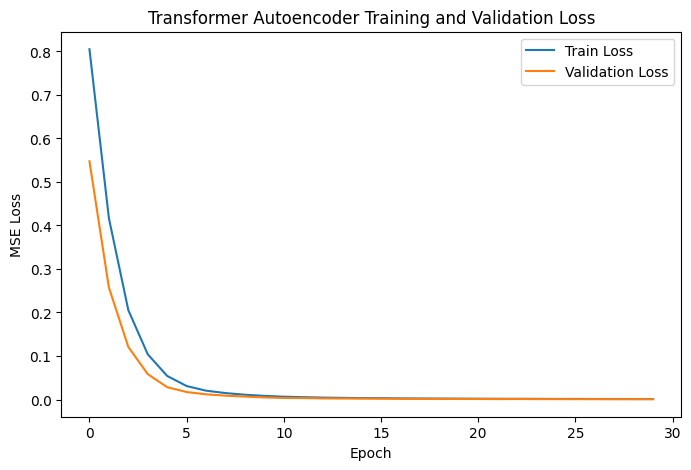

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Transformer Autoencoder Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [19]:
X_val_pred = model.predict(X_val)

val_mse = np.mean(np.power(X_val - X_val_pred, 2), axis=(1, 2))

print("Mean Reconstruction Error:", val_mse.mean())
print("Standard Deviation:", val_mse.std())
print("Maximum Reconstruction Error:", val_mse.max())

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step
Mean Reconstruction Error: 0.0006818350635393498
Standard Deviation: 0.00016994667703249214
Maximum Reconstruction Error: 0.0018165012417353148


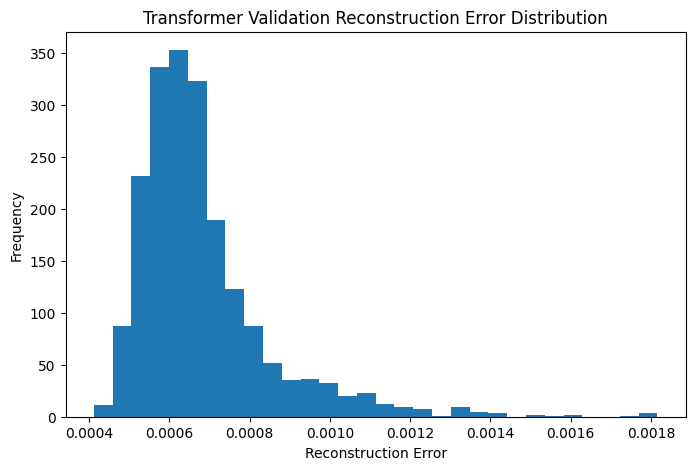

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(val_mse, bins=30)
plt.title("Transformer Validation Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.show()

In [21]:
threshold = val_mse.mean() + 3 * val_mse.std()
print("Anomaly Threshold:", threshold)

Anomaly Threshold: 0.0011916750946368263


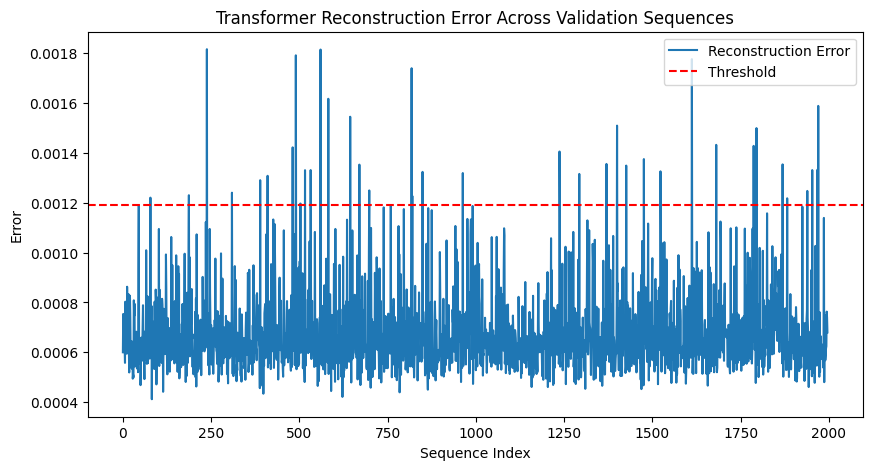

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(val_mse, label="Reconstruction Error")
plt.axhline(threshold, color="red", linestyle="--", label="Threshold")
plt.title("Transformer Reconstruction Error Across Validation Sequences")
plt.xlabel("Sequence Index")
plt.ylabel("Error")
plt.legend()
plt.show()

In [23]:
anomaly_flags = val_mse > threshold

print("Potential anomalies found:", anomaly_flags.sum())
print("Total validation sequences:", len(anomaly_flags))
print("Percentage flagged:", (anomaly_flags.sum() / len(anomaly_flags)) * 100, "%")

Potential anomalies found: 37
Total validation sequences: 1997
Percentage flagged: 1.8527791687531296 %


In [24]:
model.save("train3_transformer_autoencoder.keras")
joblib.dump(scaler, "train3_transformer_scaler.pkl")

print("Transformer model and scaler saved successfully.")

Transformer model and scaler saved successfully.


In [25]:
results_df = pd.DataFrame({
    "sequence_index": np.arange(len(val_mse)),
    "reconstruction_error": val_mse,
    "is_above_threshold": anomaly_flags
})

results_df.to_csv("train3_transformer_results.csv", index=False)

print("Results saved to train3_transformer_results.csv")
results_df.head()

Results saved to train3_transformer_results.csv


,sequence_index,reconstruction_error,is_above_threshold
0,0,0.000600,False
1,1,0.000754,False
2,2,0.000607,False
3,3,0.000679,False
4,4,0.000635,False
